## SNOTEL QC Development
Evaluate some approaches to doing QC on SNOTEL data.

In [1]:
%matplotlib ipympl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, date
from buildforcing.datasets import PNNLSnotel

### Load Data
I only care about the range of data used in the downscaling, so I'll limit the data to that range using the find_usable_dates function from buildforcing.

In [2]:
import os
snotel = PNNLSnotel(site_name='Baldy', storage_path=os.environ['SNOTEL_PATH'])
snotel.load_data()

# print latitude and longitude for reference
print(f"Latitude: {snotel.latitude}, Longitude: {snotel.longitude}")

Latitude: 33.98, Longitude: -109.5


In [3]:
start_date, end_date = snotel.find_usable_dates()
print(f"Usable dates: {start_date} to {end_date}")

Usable dates: 1988-09-27 to 2021-09-30


In [4]:
# Extract SNOTEL data for the usable date range or starting in 1990, whichever is later
if start_date < date(1990, 1, 1):
    start_date = date(1990, 1, 1)

snotel_data = snotel.data[start_date.strftime('%Y-%m-%d'):end_date.strftime('%Y-%m-%d')]

I think most of the datasets are daily with Nans for missing data, but it seems reasonable to ensure that is the case.

In [5]:
# Ensure index is daily
snotel_data = snotel_data.asfreq('D')

#### Visualization

In [6]:
# Calculate F temperatures for easier analysis
snotel_data['T_max_F'] = snotel_data['T_max_C'] * 9/5 + 32
snotel_data['T_min_F'] = snotel_data['T_min_C'] * 9/5 + 32
snotel_data['T_avg_F'] = snotel_data['T_avg_C'] * 9/5 + 32

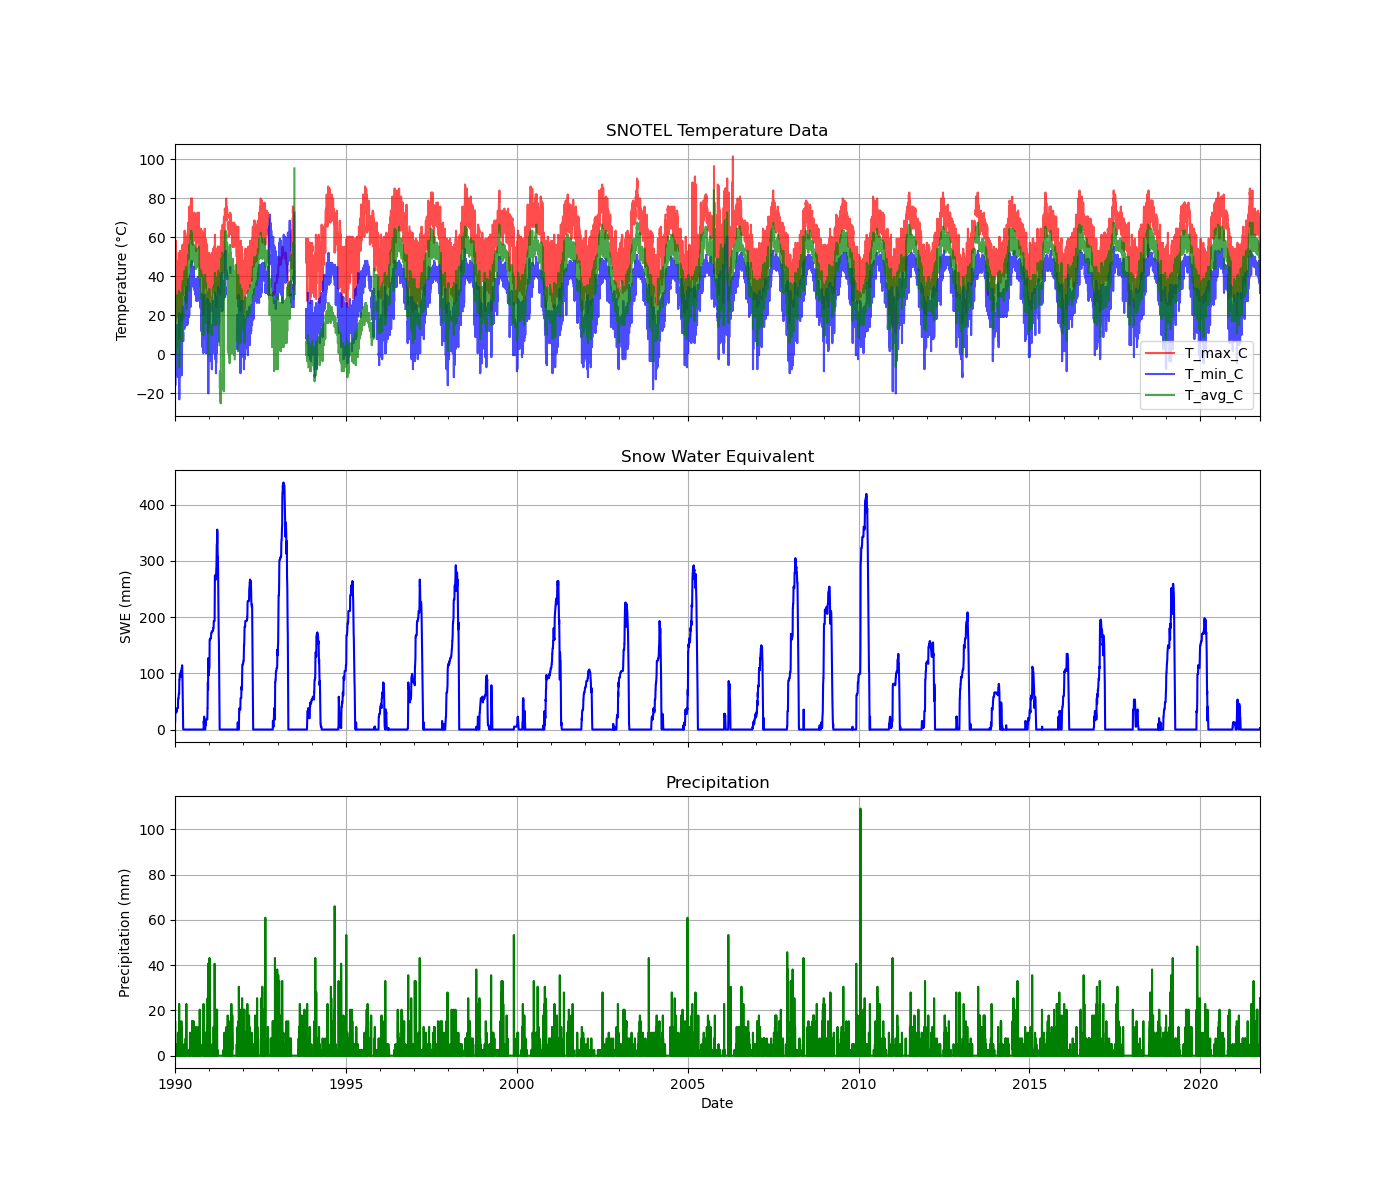

In [7]:
# Create a single figure with 3 subplots (temperature, SWE, precipitation)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plot temperatures in the top subplot
snotel_data['T_max_F'].plot(ax=ax1, label='T_max_C', color='red', alpha=0.7)
snotel_data['T_min_F'].plot(ax=ax1, label='T_min_C', color='blue', alpha=0.7)
snotel_data['T_avg_F'].plot(ax=ax1, label='T_avg_C', color='green', alpha=0.7)
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('SNOTEL Temperature Data')
ax1.legend()
ax1.grid(True)

# Plot SWE in the middle subplot
ax2.plot(snotel_data.index, snotel_data['swe_mm'], color='blue')
ax2.set_ylabel('SWE (mm)')
ax2.set_title('Snow Water Equivalent')
ax2.grid(True)

# Plot Precipitation in the bottom subplot
ax3.plot(snotel_data.index, snotel_data['precip_mm'], color='green')
ax3.set_xlabel('Date')
ax3.set_ylabel('Precipitation (mm)')
ax3.set_title('Precipitation')
ax3.grid(True)

plt.show()

Extract sections of interest for manual review.

In [8]:
review_section = snotel_data.loc['1992-10-01':'1993-07-01', ['T_max_C', 'T_min_C', 'T_avg_C']]
test_section = snotel_data.loc['1992-01-01':'1994-07-01', ['T_max_C', 'T_min_C', 'T_avg_C']]

### QC approaches
I'll start by flagging values, then decide if I want to remove them or fill them later.

In [9]:
# I can't use days with only a max or a min. Set those to NaN for now.
test_section.loc[test_section['T_max_C'].isna() | test_section['T_min_C'].isna(), ['T_max_C', 'T_min_C', 'T_avg_C']] = np.nan

#### Check 1.
Ensure consistency between temperature variables (T_max, T_min, T_avg).
- T_max should always be >= T_min
- T_avg should always be between T_max and T_min

In [ ]:
test_section['bad_max_min'] = test_section['T_max_C'] < test_section['T_min_C']
test_section['avg_not_between'] = ~test_section['T_avg_C'].between(test_section['T_min_C'], test_section['T_max_C'])

In [ ]:
test_section['flagged'] = test_section['bad_max_min'] | test_section['avg_not_between']

In [ ]:
# Plot test section with flags
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(test_section.index, test_section['T_max_C'], label='T_max_C', color='red', alpha=0.7)
ax.plot(test_section.index, test_section['T_min_C'], label='T_min_C', color='blue', alpha=0.7)
ax.plot(test_section.index, test_section['T_avg_C'], label='T_avg_C', color='green', alpha=0.7)
ax.scatter(test_section.index[test_section['flagged']], test_section['T_avg_C'][test_section['flagged']], color='black', label='Flagged', zorder=5)
ax.set_ylabel('Temperature (°C)')
ax.set_title('Temperature Data with Flags')
ax.legend()
ax.grid(True)

I have found data where the average is clearly bad, but the the max and min are reasonable. If I don't know if the average is good, I can't use it because it will create false flags.